In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [3]:
# Read in the anndata object 
import anndata as ad
import anndata as ad
from pathlib import Path
import numpy as np
import sys 

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *

splice_adata = ad.read_h5ad("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-05-13/2025-06-14/param_id_1/data/splice_adata_PHI_psi_var_obs.h5ad")

# Set model training date and base directories
MODEL_TRAIN_DATE = "2025-05-13"
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"

# Construct all paths using f-strings or pathlib
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
ATSE_ANNDATA_PATH = f"{BASE_DIR}/MODEL_INPUT/052025/MOUSE_SPLICING_FOUNDATION_Anndata_ATSE_counts_with_waypoints_20250513_073829.h5ad"
GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_{MODEL_TRAIN_DATE}.h5ad"
GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_models_2025-05-16.h5ad"
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"
RESULTS_BASE_DIR = f"/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/{MODEL_TRAIN_DATE}"
ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-04-26_19-55-26.txt.gz"

final_cells = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/062025/filtered_cell_ids.txt"
with open(final_cells, "r") as f:
    final_cells = f.read().splitlines()

# Load splicing data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
ge_adata_nmf = ad.read_h5ad(GE_ANNDATA_NMF_PATH)
# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
    ge_adata_nmf.obs["cell_id"] = ge_adata_nmf.obs["cell_id_clean"]

# Only subset by final_cells if in mouse so check if "MOUSE_" is in ATSE_ANNDATA_PATH
if "MOUSE_" in ATSE_ANNDATA_PATH:
    print("   :gear: Subsetting to final cells (outlier removal)...")
    ge_adata = ge_adata[ge_adata.obs["cell_id"].isin(final_cells)].copy()
    ge_adata_nmf = ge_adata_nmf[ge_adata_nmf.obs["cell_id"].isin(final_cells)].copy()

assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
    
# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)
    # Update gene annotations
    ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
    ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
    rbps = rbps["mouse_gene_name"]
    print(ge_adata.var["RBP_gene"])
    print(ge_adata.var["Aging_gene"])

assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell IDs in ge_adata and ge_adata_nmf do not match or are not in the same order."
assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene names in ge_adata and ge_adata_nmf do not match or are not in the same order."
ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]

# Check if predicted_log_norm_tms not in ge_adata.layers then ge_layer_name="log_norm"
if "predicted_log_norm_tms" not in ge_adata.layers:
    ge_layer_name = "log_norm"
else:
    ge_layer_name = "predicted_log_norm_tms"

   :gear: Subsetting to final cells (outlier removal)...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins


In [36]:
ATSE_ANNDATA_PATH=f"{BASE_DIR}/MODEL_INPUT/052025/MOUSE_SPLICING_FOUNDATION_Anndata_ATSE_counts_with_waypoints_20250513_073829.h5ad"
splice_adata = ad.read_h5ad(ATSE_ANNDATA_PATH)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [37]:
splice_adata

AnnData object with n_obs × n_vars = 157418 × 16530
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'broad_cell_type', 'seqtech'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'junction_id_index'
    uns: 'pca_explained_variance_ratio'
    obsm: 'X_pca', 'phi_init_30_waypoints'
    varm: 'psi_init_30_waypoints'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix', 'junc_ratio'

In [38]:
import scipy.sparse as sp

# Ensure correct matrix
cell_by_junction = splice_adata.layers["cell_by_junction_matrix"]
if not sp.issparse(cell_by_junction):
    cell_by_junction = sp.csr_matrix(cell_by_junction)

# Compute per-cell read counts
splice_adata.obs["reads_per_cell"] = np.ravel(cell_by_junction.sum(axis=1))

# Compute per-cell non-zero junction count
splice_adata.obs["junctions_detected_per_cell"] = np.ravel((cell_by_junction > 0).sum(axis=1))

# Compute per-junction read counts
splice_adata.var["reads_per_junction"] = np.ravel(cell_by_junction.sum(axis=0))

# ---- Summary Statistics ----
print("Reads per cell:\n", splice_adata.obs["reads_per_cell"].describe())
print("\nJunctions with reads > 0 per cell:\n", splice_adata.obs["junctions_detected_per_cell"].describe())
print("\nReads per junction:\n", splice_adata.var["reads_per_junction"].describe())


Reads per cell:
 count    1.574180e+05
mean     5.272404e+04
std      8.773056e+04
min      0.000000e+00
25%      1.675100e+04
50%      3.520250e+04
75%      6.309300e+04
max      6.442996e+06
Name: reads_per_cell, dtype: float64

Junctions with reads > 0 per cell:
 count    157418.000000
mean       1876.933496
std        1699.930602
min           0.000000
25%         520.000000
50%        1187.000000
75%        3167.750000
max        8248.000000
Name: junctions_detected_per_cell, dtype: float64

Reads per junction:
 count    1.653000e+04
mean     5.021000e+05
std      1.986239e+06
min      2.505000e+03
25%      2.818700e+04
50%      8.547900e+04
75%      3.269648e+05
max      9.190851e+07
Name: reads_per_junction, dtype: float64


In [64]:
splice_adata.obs[splice_adata.obs["junctions_detected_per_cell"] >600]

,cell_id_index,age,cell_ontology_class,mouse.id,sex,subtissue,tissue,dataset,cell_name,cell_id,cell_clean,broad_cell_type,seqtech,reads_per_cell,junctions_detected_per_cell
1,1,3m,bulge keratinocyte,3_39_F,female,Telogen,Skin,TMS,A10_B000126,A10_B000126,A10_B000126,KERATINOCYTE,single_cell,18124,1014
3,3,3m,basal cell,3_56_F,female,Mammary_Gland,Mammary_Gland,TMS,A10_B000166,A10_B000166,A10_B000166,BASAL CELL,single_cell,142122,2177
8,8,18m,enterocyte of epithelium of large intestine,18_53_M,male,Proximal,Large_Intestine,TMS,A10_B000232,A10_B000232,A10_B000232,EPITHELIAL CELL,single_cell,171232,2081
9,9,18m,intestinal crypt stem cell,18_53_M,male,Distal,Large_Intestine,TMS,A10_B000246,A10_B000246,A10_B000246,STEM CELL,single_cell,64262,2034
11,11,18m,mucus secreting cell,18_46_F,female,NaN,Trachea,TMS,A10_B000263,A10_B000263,A10_B000263,SECRETORY CELL,single_cell,52016,834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157413,157413,2m,197_L5 IT CTX,184750,F,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S86,US-1250275_E2_S86,SRR16457632,Excitatory Neurons,single_nuclei,26251,4561
157414,157414,2m,204_L5/6 IT CTX,184756,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S87,US-1250275_E2_S87,SRR16457633,Excitatory Neurons,single_nuclei,20658,4217
157415,157415,2m,257_L5 PT CTX,185199,M,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S88,US-1250275_E2_S88,SRR16457635,Excitatory Neurons,single_nuclei,23580,4977
157416,157416,2m,204_L5/6 IT CTX,185200,F,VISp,Brain_Non-Myeloid,AB,US-1250275_E2_S89,US-1250275_E2_S89,SRR16457636,Excitatory Neurons,single_nuclei,36530,5647


In [ ]:
rbps

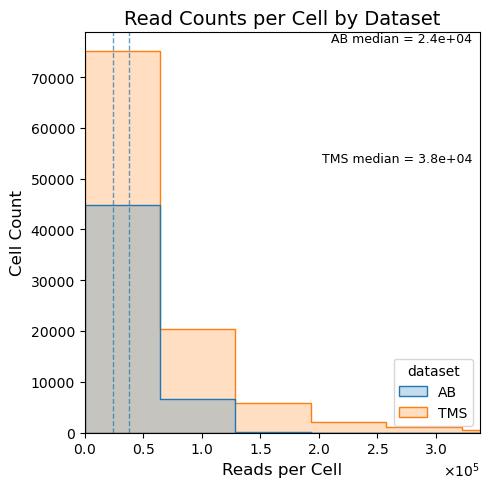

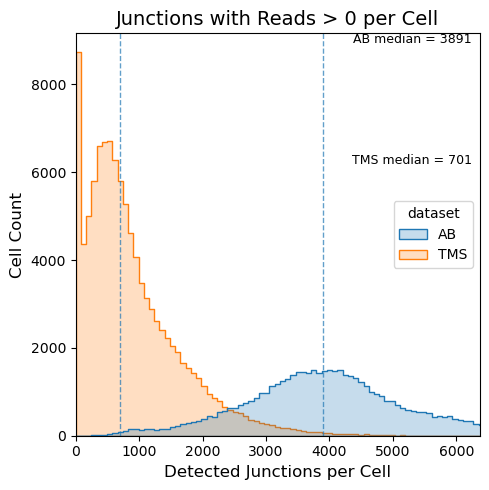

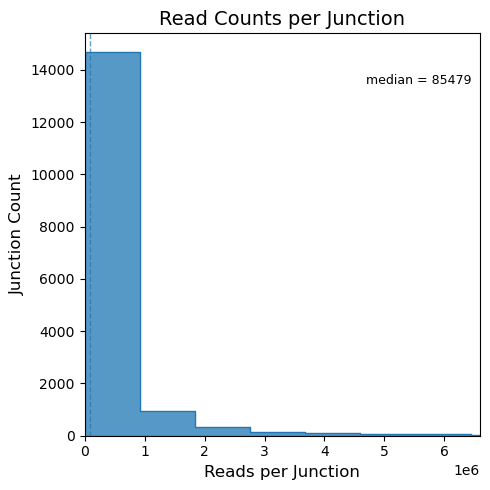

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter

# === Plot 1: Reads per Cell by Dataset (with scientific notation) ===
plt.figure(figsize=(5, 5))
sns.histplot(data=splice_adata.obs, x="reads_per_cell", hue="dataset", bins=100,
             multiple="layer", element="step")
plt.title("Read Counts per Cell by Dataset", fontsize=14)
plt.xlabel("Reads per Cell", fontsize=12)
plt.ylabel("Cell Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(splice_adata.obs["reads_per_cell"], 99))

# Use scientific notation on x-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# Add median lines + labels
ylim = plt.ylim()
line_spacing = (ylim[1] * 0.9) / (len(splice_adata.obs["dataset"].unique()) + 1)
for i, ds in enumerate(sorted(splice_adata.obs["dataset"].unique())):
    median_val = splice_adata.obs.loc[splice_adata.obs["dataset"] == ds, "reads_per_cell"].median()
    plt.axvline(median_val, linestyle="--", linewidth=1, alpha=0.7)
    plt.text(plt.xlim()[1] * 0.98, ylim[1] - i * line_spacing,
             f"{ds} median = {int(median_val):.1e}",
             ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.savefig("reads_per_cell_by_dataset.pdf")

# === Plot 2: Junctions Detected per Cell ===
plt.figure(figsize=(5, 5))
sns.histplot(data=splice_adata.obs, x="junctions_detected_per_cell", hue="dataset", bins=100,
             multiple="layer", element="step")
plt.title("Junctions with Reads > 0 per Cell", fontsize=14)
plt.xlabel("Detected Junctions per Cell", fontsize=12)
plt.ylabel("Cell Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(splice_adata.obs["junctions_detected_per_cell"], 99))

ylim = plt.ylim()
line_spacing = (ylim[1] * 0.9) / (len(splice_adata.obs["dataset"].unique()) + 1)
for i, ds in enumerate(sorted(splice_adata.obs["dataset"].unique())):
    median_val = splice_adata.obs.loc[splice_adata.obs["dataset"] == ds, "junctions_detected_per_cell"].median()
    plt.axvline(median_val, linestyle="--", linewidth=1, alpha=0.7)
    plt.text(plt.xlim()[1] * 0.98, ylim[1] - i * line_spacing,
             f"{ds} median = {int(median_val)}",
             ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.savefig("junctions_per_cell_by_dataset.pdf")

# === Plot 3: Reads per Junction ===
plt.figure(figsize=(5, 5))
sns.histplot(splice_adata.var["reads_per_junction"], bins=100, element="step")
plt.title("Read Counts per Junction", fontsize=14)
plt.xlabel("Reads per Junction", fontsize=12)
plt.ylabel("Junction Count", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, np.percentile(splice_adata.var["reads_per_junction"], 99))

median_val = splice_adata.var["reads_per_junction"].median()
plt.axvline(median_val, linestyle="--", linewidth=1, alpha=0.7)
plt.text(plt.xlim()[1] * 0.98, plt.ylim()[1]*0.9,
         f"median = {int(median_val)}", ha="right", va="top", fontsize=9)

plt.tight_layout()
plt.savefig("reads_per_junction.pdf")


In [4]:
# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
# If perfect_match_5_prime is nonempty then set junction_annotation to "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
# If perfect_match_3_prime is nonempty then set junction_annotation to "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
# If perfect_match_5_prime and perfect_match_3_prime are both nonempty then set junction_annotation to "Both_SS_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

In [5]:
# get final count of cells by dataset and age group 
splice_adata.obs[["dataset", "age_numeric"]].value_counts()

dataset  age_numeric
AB       2              51074
TMS      3              38630
         18             29578
         24             26699
Name: count, dtype: int64

In [6]:
splice_adata.var["event_id"].nunique()

5917

In [9]:
splice_adata.var[splice_adata.var["junction_id_index"] == 10217]

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,junction_id_index,RBP_gene,Aging_gene
10217,chr4_123361027_123365272_-,ATSE_3352,GT-AG,both,Macf1,ENSMUSG00000028649,3,1.0,0.0,93583,2582,0.016402,2.0,1.5,10217,False,True


In [18]:
df = atse_df[["event_id", "junction_id", "gene_name", "gene_types", "num_junctions", "transcript_types", "perfect_match_5_prime", "perfect_match_3_prime", "junction_annotation", "splice_motif", "cells", "total_score"]]

In [35]:
# get summary matrics, how many cells have each junction detected with raw counts > 0 
splice_adata.var

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,junction_id_index,RBP_gene,Aging_gene
0,chr10_100080130_100080856_+,ATSE_9090,GT-AG,both,Kitl,ENSMUSG00000019966,3,0.0,1.0,199659,10236,0.065024,2.0,1.5,0,False,False
1,chr10_100080130_100087346_+,ATSE_9090,GT-AG,both,Kitl,ENSMUSG00000019966,3,0.0,1.0,111965,2612,0.016593,2.0,1.5,1,False,False
2,chr10_100080940_100087346_+,ATSE_9090,GT-AG,both,Kitl,ENSMUSG00000019966,3,0.0,1.0,180991,10011,0.063595,2.0,1.5,2,False,False
3,chr10_100578431_100582262_-,ATSE_10708,GT-AG,both,4930430F08Rik,ENSMUSG00000046567,3,1.0,0.0,15990,2060,0.013086,2.0,1.5,3,False,False
4,chr10_100578431_100583913_-,ATSE_10708,GT-AG,both,4930430F08Rik,ENSMUSG00000046567,3,1.0,0.0,139350,22988,0.146032,2.0,1.5,4,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16525,chrX_99468314_99470616_-,ATSE_5473,GT-AG,both,Pja1,ENSMUSG00000034403,2,1.0,0.0,1197256,66480,0.422315,2.0,1.5,16525,False,False
16526,chrX_99468600_99470616_-,ATSE_5473,GT-AG,both,Pja1,ENSMUSG00000034403,2,1.0,0.0,61321,5285,0.033573,2.0,1.5,16526,False,False
16527,chrY_1168185_1169122_-,ATSE_11862,GT-AG,both,Uty,ENSMUSG00000068457,3,1.0,0.0,19059,2603,0.016536,2.0,1.5,16527,False,False
16528,chrY_1168185_1169964_-,ATSE_11862,GT-AG,both,Uty,ENSMUSG00000068457,3,1.0,0.0,11564,2399,0.015240,2.0,1.5,16528,False,False


Visualizing mouse ATSE: ATSE_12971
[]
Unique transcripts: ['ENSMUST00000029368.6', 'ENSMUST00000197238.4', 'ENSMUST00000198102.4', 'ENSMUST00000198320.4']
Unique transcripts to remove: []
Plot saved to mouse_ATSE_12971.pdf!


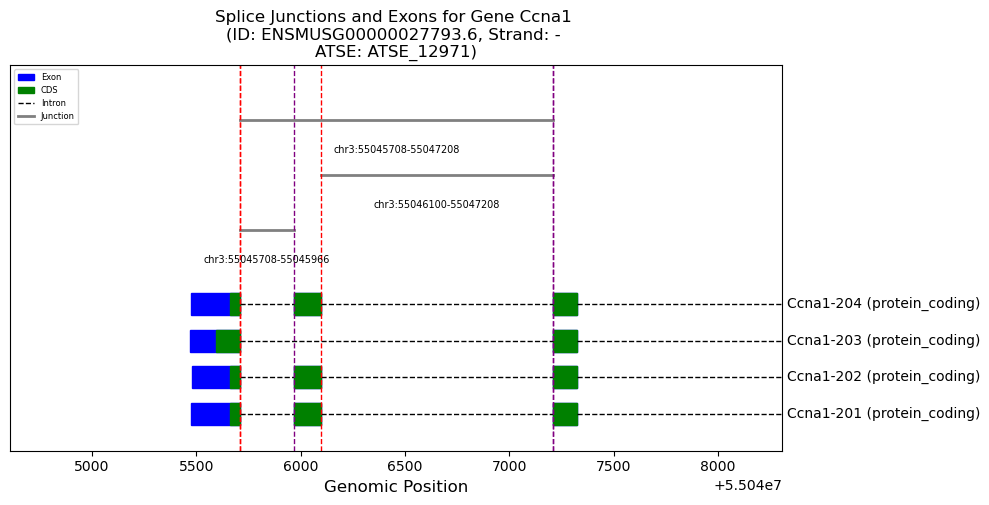

ATSE visualization saved: mouse_ATSE_12971.pdf


{'junctions':          event_id               gene_id gene_name      gene_types  \
 34840  ATSE_12971  ENSMUSG00000027793.6     Ccna1  protein_coding   
 34841  ATSE_12971  ENSMUSG00000027793.6     Ccna1  protein_coding   
 34842  ATSE_12971  ENSMUSG00000027793.6     Ccna1  protein_coding   
 
        num_junctions event_type transcript_types annotation_status  \
 34840              3  exon_skip   protein_coding              both   
 34841              3  exon_skip   protein_coding              both   
 34842              3  exon_skip   protein_coding              both   
 
                                    perfect_match_5_prime  \
 34840  ENSMUST00000029368.6,ENSMUST00000198320.4,ENSM...   
 34841  ENSMUST00000198102.4,ENSMUST00000029368.6,ENSM...   
 34842  ENSMUST00000198102.4,ENSMUST00000029368.6,ENSM...   
 
                                    perfect_match_3_prime  ...  \
 34840  ENSMUST00000198102.4,ENSMUST00000029368.6,ENSM...  ...   
 34841  ENSMUST00000029368.6,ENSMUST00000

In [32]:
mouse_event="ATSE_12971"
print(f"Visualizing mouse ATSE: {mouse_event}")
print(splice_adata.var[splice_adata.var["event_id"] == mouse_event]["junction_id_index"].values)
visualize_atse_event(mouse_event, atse_df, db_mouse,
                           species="mouse",
                           padding=100, show_junc_lines=True)

In [ ]:
mouse_event = atse_df[atse_df["gene_name"] == "Macf1"]["event_id"].values
# get unique mouse_event
mouse_event = np.unique(mouse_event)
print(f"Number of unique mouse events: {len(mouse_event)}")

# If more than one plot each one 
if len(mouse_event) > 1:    
    for event in mouse_event:
        print(f"Visualizing mouse ATSE: {event}")
        print(splice_adata.var[splice_adata.var["event_id"] == event]["junction_id_index"].values)
        visualize_atse_event(event, atse_df, db_mouse,
                           species="mouse",
                           padding=5000, show_junc_lines=True)
else:
    print(f"Visualizing mouse ATSE: {mouse_event}")
    visualize_atse_event(mouse_event, atse_df, db_mouse,
                   species="mouse",width=12,
                   padding=5000, show_junc_lines=True)

In [ ]:
mouse_event = "ATSE_3352"
visualize_atse_event(mouse_event, atse_df, db_mouse,
                   species="mouse", base_width=7, 
                        trans_height=0.2, 
                   padding=200, show_junc_lines=True)

In [ ]:
groupby="broad_cell_type"
# Extract PHI matrix
X_PHI = splice_adata.obsm["X_PHI"]
n_factors = X_PHI.shape[1]
factor_cols = [f"factor_{i}" for i in range(n_factors)]

# within each cell type, get factor delta between young and old, median (old) - median (young) 
df_all = pd.DataFrame(X_PHI, columns=factor_cols)
df_all[groupby] = splice_adata.obs[groupby].values
df_all["age_group"] = splice_adata.obs["age_group"].values
# Group by groupby + age_group
median_by_group_and_age = df_all.groupby([groupby, "age_group"], observed=True)[factor_cols].median()
# Pivot into two matrices: one for young, one for old
median_young = median_by_group_and_age.xs("young", level="age_group")
median_old = median_by_group_and_age.xs("old", level="age_group")
# Align index (cell types) and subtract
delta_median = median_old - median_young    
delta_median = delta_median.fillna(0)

# Save delta matrix
# Reorder delta_median based on median_expression clustermap (g2)
# Plot delta clustermap (same row/col order as mean_expression)
g4 = sns.clustermap(
    delta_median,
    cmap="BrBG",
    center=0,
    figsize=(5, 4),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'Δ(Old - Young)'},
    linewidths=0.2,
    linecolor='gray',
    row_cluster=True,
    col_cluster=True
)
# Use same tick label formatting
plt.setp(g4.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=6)
plt.setp(g4.ax_heatmap.get_yticklabels(), rotation=0, fontsize=5)
g4.ax_cbar.set_ylabel("Δ(Old - Young)", fontsize=8)  # Set your desired size
g4.ax_cbar.tick_params(labelsize=6)
# Change xlab to "Broad Cell Type"
plt.savefig("delta_median_old_minus_young_by_broad_cell_type.pdf", format="pdf")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Extract matrix
X_PHI = splice_adata.obsm["X_PHI"]
n_factors = X_PHI.shape[1]
factor_cols = [f"factor_{i}" for i in range(n_factors)]

# Build DataFrame
df_all = pd.DataFrame(X_PHI, columns=factor_cols)
df_all[groupby] = splice_adata.obs[groupby].values

# Set zero values to NaN to ignore them in median calculation
df_all_nonzero = df_all.copy()
df_all_nonzero[factor_cols] = df_all_nonzero[factor_cols].mask(df_all_nonzero[factor_cols] == 0)

# Compute median nonzero activity for each cell type and factor
median_nonzero = df_all_nonzero.groupby(groupby, observed=True)[factor_cols].median()
median_nonzero = median_nonzero.fillna(0)

# Use same row/col order as g4
row_order = [median_nonzero.index[i] for i in g4.dendrogram_row.reordered_ind]
col_order = [median_nonzero.columns[i] for i in g4.dendrogram_col.reordered_ind]
median_nonzero = median_nonzero.loc[row_order, col_order]

# Plot
g5 = sns.clustermap(
    median_nonzero,
    cmap="PRGn",
    center=0,
    figsize=(5, 4),
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'Median Factor Activity (nonzero)'},
    row_cluster=False,
    col_cluster=False,
    linewidths=0.2,
    linecolor='gray'
)

plt.setp(g5.ax_heatmap.get_xticklabels(), rotation=90, ha='right', fontsize=6)
plt.setp(g5.ax_heatmap.get_yticklabels(), rotation=0, fontsize=5)
g5.ax_cbar.set_ylabel("Median Nonzero \nFactor Activity", fontsize=6)  # Set your desired size
g5.ax_cbar.tick_params(labelsize=6)


plt.savefig("median_nonzero_factor_activity_by_broad_cell_type.pdf", format="pdf")


In [10]:
# read in factor labels 
factor_labels = pd.read_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-05-13/2025-06-14/param_id_1/data/factor_label_df.csv")

In [ ]:
factor_labels

In [12]:
def relabel_covariate(row):
    covs = row['top_covariates']
    has_celltype = 'C(cell_type)' in covs
    has_age = 'age' in covs
    has_tissue = 'C(tissue)' in covs
    has_sex = 'C(sex)' in covs
    has_interaction = 'C(cell_type):age' in covs

    labels = []

    if has_interaction:
        labels.append('cell_type:age')
    if has_celltype:
        labels.append('cell_type')
    if has_age:
        labels.append('age')
    if has_tissue:
        labels.append('tissue')
    if has_sex:
        labels.append('sex')

    return ' + '.join(labels) if labels else 'other'

factor_labels['combined_label'] = factor_labels.apply(relabel_covariate, axis=1)

In [ ]:
pi="/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-05-13/2025-06-14/param_id_1/data/PI_values.npy"
pi = np.load(pi)
pi

In [ ]:
# Create DataFrame for pi values
pi_df = pd.DataFrame({
    "factor_id": [f"factor_{i}" for i in range(len(pi))],
    "PI": pi
})

# Merge with factor_labels by factor_id
df = factor_labels.merge(pi_df, on="factor_id")

# Sort by R²
df = df.sort_values("r2", ascending=False).copy()

# Add rank and formatted label
df["rank"] = range(1, len(df) + 1)

# Plot
plt.figure(figsize=(4, 6))
ax = sns.barplot(data=df, y="factor_id", x="r2", hue="combined_label", dodge=False)

# Add dashed red line at R^2 = 0.5
plt.axvline(x=0.5, color='grey', linestyle='--', linewidth=1)

# Annotate each bar with PI value
for i, (r2_val, pi_val) in enumerate(zip(df["r2"], df["PI"])):
    ax.text(
        x=r2_val + 0.01,
        y=i,
        s=f"PI={pi_val:.2f}",
        va='center',
        ha='left',
        fontsize=8
    )

plt.xlabel("R² (Explained Variance)")
plt.ylabel("Factor")
plt.tight_layout()

# Make legend smaller
#plt.legend(title="Top Covariate", bbox_to_anchor=(1.05, 0.8), loc='upper left', fontsize=8)
plt.savefig("top_covariates_explaining_each_factor.pdf", format="pdf")

plt.show()


In [15]:
# Create column names
factor_cols = [f"Factor_{i}" for i in range(splice_adata.obsm["X_PHI"].shape[1])]

# Convert to DataFrame
phi_df = pd.DataFrame(splice_adata.obsm["X_PHI"], columns=factor_cols, index=splice_adata.obs_names)

# Merge into obs
splice_adata.obs = splice_adata.obs.join(phi_df)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

def plot_factor_corr(splice_adata, f_x, f_y, *, gridsize=60, zero_based=False):
    """
    Hex-bin scatter of learned ψ for two factors, with Pearson & Spearman r.

    Parameters
    ----------
    splice_adata : AnnData
        Must contain varm["psi_learned"] with shape (J, K).
    f_x, f_y : int
        Factor numbers as you think of them (e.g. 2, 15).  By default these
        are treated as *1-based*; set zero_based=True if you want 0-based.
    gridsize : int, optional
        Hex-bin resolution (higher → finer).
    zero_based : bool, optional
        If True, treat f_x and f_y as 0-based indices.
    """
    # --- translate to python indices -----------------------------------------
    ix_x = f_x if zero_based else f_x - 1
    ix_y = f_y if zero_based else f_y - 1

    ψ = splice_adata.varm["psi_learned"]
    x, y = ψ[:, ix_x], ψ[:, ix_y]           # keep caller’s order: x first

    # --- correlations --------------------------------------------------------
    pearson_r  = np.corrcoef(x, y)[0, 1]
    spearman_r = spearmanr(x, y, nan_policy="omit").correlation

    # --- plot ---------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(5, 4))
    hb = ax.hexbin(
        x, y,
        gridsize=gridsize,
        bins="log",
        linewidth=0,
        cmap="viridis"
    )
    fig.colorbar(hb, ax=ax, label="log₁₀ (# junctions)")

    ax.set_xlabel(f"ψ (factor {f_x})")
    ax.set_ylabel(f"ψ (factor {f_y})")
    ax.set_title(
        f"Factor {f_x} vs {f_y}\n"
        f"Pearson r = {pearson_r:.2f}   •   Spearman ρ = {spearman_r:.2f}"
    )

    plt.tight_layout()
    plt.show()

# examples ───────────────────────────────────────────────────────────────────
plot_factor_corr(splice_adata, f_x=17,  f_y=20)       # factors 2 vs 15, 1-based

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests   # pip install statsmodels

# ── 1.  Data → DataFrame ───────────────────────────────────────────────────────
ψ  = splice_adata.varm["psi_learned"]          # (J, K)
K  = ψ.shape[1]
df = pd.DataFrame(ψ, columns=[f"F{j+1}" for j in range(K)])

# ── 2.  ρ and p-values for *each* pair ─────────────────────────────────────────
rho    = np.zeros((K, K))
pvals  = np.ones((K, K))

for i in range(K):
    for j in range(i+1, K):
        r, p = spearmanr(df.iloc[:, i], df.iloc[:, j], nan_policy='omit')
        rho[i, j] = rho[j, i] = r
        pvals[i, j] = pvals[j, i] = p

# ── 3.  Benjamini–Hochberg FDR adjustment over the upper triangle ─────────────
tri_idx         = np.triu_indices(K, k=1)          # exclude the diagonal
p_flat          = pvals[tri_idx]
_, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")
qvals           = np.ones_like(pvals)
qvals[tri_idx]  = qvals.T[tri_idx] = q_flat

# ── 4.  Significance mask  (FDR < 0.05 and ρ > 0.20) ──────────────────────────
star_mask = (qvals < 0.05) & (rho > 0.20)
annot     = np.where(star_mask, "*", "")

# ── 5.  Build DataFrames with indices/columns for seaborn ─────────────────────
rho_df   = pd.DataFrame(rho,   index=df.columns, columns=df.columns)
annot_df = pd.DataFrame(annot, index=df.columns, columns=df.columns)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ── 0.  rho_df must exist (K × K DataFrame) ───────────────────────────────────
#       and you probably still have annot_df if you want the stars

# ── 1.  clustered heat-map with all tick labels ───────────────────────────────
sns.set_theme(style="white")
g = sns.clustermap(
    rho_df,
    cmap="vlag", center=0, linewidths=0.4, square=True,
    metric="euclidean", row_cluster=True, col_cluster=True,
    figsize=(6, 6),
    annot=annot_df, fmt="", annot_kws={"size":7},
    xticklabels=True, yticklabels=True
)

# Rotate x-labels so they don’t overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.ax_heatmap.set_title("Spearman ρ between ψ-factors\n*  FDR < 0.05 & ρ > 0.20  *", pad=14)
g.ax_heatmap.set_xlabel("Factors")
g.ax_heatmap.set_ylabel("Factors")

plt.tight_layout()

# ── 2.  save to disk ──────────────────────────────────────────────────────────
g.savefig("psi_factor_spearman_clustermap.pdf", bbox_inches="tight")

# ── 3.  report extreme pairs ──────────────────────────────────────────────────
# flatten upper triangle (exclude diagonal), keep finite values only
tri_i, tri_j = np.triu_indices_from(rho_df, k=1)
tri_vals = rho_df.values[tri_i, tri_j]

# build a DataFrame for easy sorting
pairs_df = pd.DataFrame({
    "factor_i": rho_df.index[tri_i],
    "factor_j": rho_df.columns[tri_j],
    "rho":      tri_vals
}).dropna()

# top 2 positive
top_pos = pairs_df.nlargest(2, "rho")
# top 2 negative
top_neg = pairs_df.nsmallest(2, "rho")
# top 2 least correlated (closest to zero)
top_flat = pairs_df.iloc[(pairs_df["rho"].abs()).nsmallest(2).index]

print("\nTop 2 positively correlated factor pairs:")
print(top_pos.to_string(index=False))

print("\nTop 2 negatively correlated factor pairs:")
print(top_neg.to_string(index=False))

print("\nTop 2 least correlated factor pairs:")
print(top_flat.to_string(index=False))


In [31]:
# Use the updated obs DataFrame
df = splice_adata.obs
import matplotlib.pyplot as plt
import seaborn as sns

def plot_factor_violin(
    adata,
    factor_list,
    groupby="broad_cell_type",
    include_groups=None,
    figsize=(4, 4),
    save_prefix=None
):
    """
    Plot violinplots of factor activity grouped by a metadata category.

    Args:
        adata: AnnData object with factor columns in `.obs` (e.g., 'Factor_0', ...)
        factor_list: list of factor names as strings (e.g., ['Factor_0', 'Factor_3'])
        groupby: obs column to group by (e.g., 'tissue', 'age_group', etc.)
        include_groups: list of values in `groupby` to include (e.g., ['3m', '24m'])
        figsize: tuple for figure size
        save_prefix: optional prefix to save each figure as a PDF
    """
    df = adata.obs.copy()

    if include_groups is not None:
        df = df[df[groupby].isin(include_groups)]

    for factor in factor_list:
        plt.figure(figsize=figsize)
        sns.violinplot(
            data=df,
            linewidth=1, linecolor="k",
            x=groupby,    palette="Set2",
            inner="quart",
            y=factor, fill=False)
        
        plt.title(f"{factor} Activity by {groupby}")
        plt.xlabel(groupby)
        plt.ylabel("Factor Activity")
        plt.xticks(rotation=45, fontsize=14)
        plt.yticks(fontsize=14)
        plt.tight_layout()

        if save_prefix:
            plt.savefig(f"{save_prefix}_{factor}_by_{groupby}.pdf", format="pdf")
        plt.show()

In [32]:
def plot_factor_violin_sorted(
    adata,
    factor_list,
    groupby="broad_cell_type",
    include_groups=None,
    width=8,       # ← fixed width
    height=4,
    cmap="YlGnBu",
    top_n=10,
    save_prefix=None
):
    """
    Plot violin plots of factor activity grouped by a metadata field,
    showing top_n groups by median activity and collapsing the rest as 'Other'.

    Args:
        adata: AnnData object
        factor_list: list of factor column names in .obs (e.g. ['Factor_1'])
        groupby: obs column to group by (e.g., 'broad_cell_type')
        include_groups: list of groupby values to include (optional)
        width: fixed figure width
        height: fixed figure height
        cmap: matplotlib colormap name (e.g., 'YlGnBu')
        top_n: number of top groups (by median) to display; rest go into "Other"
        save_prefix: if provided, saves plots to PDF
    """
    obs_df = adata.obs.copy()
    if include_groups is not None:
        obs_df = obs_df[obs_df[groupby].isin(include_groups)]

    for factor in factor_list:
        plot_df = obs_df[[groupby, factor]].dropna()

        # Compute medians and get top_n groups
        medians = plot_df.groupby(groupby)[factor].median().sort_values(ascending=False)
        top_groups = medians.head(top_n).index.tolist()

        # Map rest to "Other"
        plot_df[groupby] = plot_df[groupby].apply(lambda x: x if x in top_groups else "Other")

        # Define plot order: top groups + Other
        plot_order = top_groups + ["Other"]

        # Categorical for ordering
        plot_df[groupby] = pd.Categorical(plot_df[groupby], categories=plot_order, ordered=True)

        # Build color palette (add grey for "Other")
        base_palette = sns.color_palette(cmap, len(top_groups))
        color_map = dict(zip(top_groups, base_palette))
        color_map["Other"] = "lightgrey"

        plt.figure(figsize=(width, height))

        sns.violinplot(
            data=plot_df,
            x=groupby,
            y=factor,
            order=plot_order,
            palette=color_map,
            inner="box",
            cut=0
        )

        plt.title(f"{factor} Activity by Top {top_n} {groupby} (+Other)")
        plt.xlabel(groupby)
        plt.ylabel("Factor Activity")
        plt.xticks(rotation=90)
        plt.tight_layout()

        if save_prefix:
            plt.savefig(f"{save_prefix}_{factor}_by_{groupby}_top{top_n}_with_other.pdf", format="pdf")

        plt.show()

In [ ]:
plot_factor_violin(
    adata=splice_adata,
    factor_list=["Factor_17", "Factor_20"],
    groupby="age_group",
    include_groups=["young", "old"],
    save_prefix="factor_age_violin"
)

In [ ]:
plot_factor_violin(
    adata=splice_adata,
    factor_list=["Factor_17", "Factor_20"],
    groupby="age_numeric",
    save_prefix="factor_age_violin"
)

In [ ]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["Factor_17", "Factor_20"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_factor_age_trends(
    df,
    factor,
    groupby="broad_cell_type",
    age_col="age_numeric",
    top_n=7,
    figsize=(4, 4),
    title_prefix=None,
    save_path=None
):
    """
    Plot median factor activity over age, labeled by top N cell types.

    Args:
        df: DataFrame (e.g., `splice_adata.obs`) with factor, groupby, and age columns
        factor: column name of the factor (e.g., "Factor_1")
        groupby: grouping variable, e.g. "broad_cell_type"
        age_col: age variable (numeric), e.g. "age_numeric"
        top_n: number of top groups to plot by median factor activity
        figsize: tuple for figure size
        title_prefix: string to prepend to title (optional)
        save_path: if given, saves the figure to this path
    """
    # Step 1: rank groups by median factor activity
    overall_median = (
        df.groupby(groupby)[factor]
        .median()
        .sort_values(ascending=False)
    )
    top_groups = overall_median.head(top_n).index.tolist()

    # Step 2: subset data
    filtered_df = df[df[groupby].isin(top_groups)]

    # Step 3: summarize median by age within group
    summary = (
        filtered_df.groupby([groupby, age_col])[factor]
        .median()
        .reset_index()
    )

    # Step 4: plot
    plt.figure(figsize=figsize)
    ax = sns.lineplot(
        data=summary,
        x=age_col,
        y=factor,
        hue=groupby,
        marker="o",
        legend=False
    )

    # Step 5: label last point per group
    for group in summary[groupby].unique():
        data_ct = summary[summary[groupby] == group]
        first = data_ct.sort_values(age_col).iloc[0]
        ax.text(
            x=first[age_col] - 0.2,
            y=first[factor],
            s=group,
            fontsize=7,
            va='center'
        )

    # Final formatting
    title = f"{factor} Median Activity by Age"
    if title_prefix:
        title = f"{title_prefix}: {title}"
    plt.title(title)
    plt.xlabel("Age (months)")
    plt.ylabel("Median Factor Activity")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format="pdf")

    plt.show()


In [ ]:
plot_factor_age_trends(
    df=splice_adata.obs,
    factor="Factor_4",
    top_n=3,
    title_prefix="Top Aging Cell Types",
    save_path="Factor_1_age_trend_top5.pdf"
)


In [ ]:
# Get cell type counts by dataset to get common cell types
# Get cell type counts by dataset to get common cell types
cell_type_counts = splice_adata.obs.groupby(['broad_cell_type', 'dataset']).size().unstack()
common_cell_types = cell_type_counts[(cell_type_counts["AB"] > 0) & (cell_type_counts["TMS"] > 0)]
common_cell_type_names = common_cell_types.index.tolist()
common_cell_type_names

In [ ]:
adata_common = splice_adata[splice_adata.obs["broad_cell_type"].isin(common_cell_type_names)].copy()
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].cat.remove_unused_categories()

# Extract factor values
num_factors = adata_common.obsm["X_PHI"].shape[1]
factor_cols = [f"Factor_{i}" for i in range(num_factors)]
df = adata_common.obs[["broad_cell_type", "dataset"]].copy()

for i, col in enumerate(factor_cols):
    df[col] = adata_common.obsm["X_PHI"][:, i]

median_profiles = (
    df.groupby(["broad_cell_type", "dataset"])[factor_cols]
    .median()
    .reset_index()
)

# Create composite label
median_profiles["label"] = (
    median_profiles["broad_cell_type"].astype(str)
    + " (" +
    median_profiles["dataset"].astype(str)
    + ")"
)

median_profiles = median_profiles.set_index("label")[factor_cols]

# Cluster heatmap
g = sns.clustermap(
    median_profiles,
    method="average",
    metric="euclidean",
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor='gray',
    figsize=(5, 4)
)

g.savefig("clustering_common_celltype_dataset_factors.pdf")

plt.show()


In [ ]:
factor_labels

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_factor_violin_by_age(
    df,
    factor,
    cell_types,
    age_col="age_numeric",
    groupby="broad_cell_type",
    figsize=(6, 4),
    title_prefix=None,
    save_path=None
):
    """
    Plot violin plots of factor activity across age (categorical) for selected cell types.
    Annotates median factor values above each violin.

    Args:
        df: DataFrame with factor and metadata
        factor: name of the factor column (e.g., "Factor_1")
        cell_types: list of cell types to include (values in groupby column)
        age_col: numeric column representing age (converted to categorical)
        groupby: metadata column representing cell type (e.g., "broad_cell_type")
        figsize: figure size tuple
        title_prefix: optional title prefix
        save_path: optional path to save figure
    """
    df_sub = df[df[groupby].isin(cell_types)].copy()

    if pd.api.types.is_categorical_dtype(df_sub[groupby]):
        df_sub[groupby] = df_sub[groupby].cat.remove_unused_categories()

    sorted_ages = sorted(df_sub[age_col].dropna().unique())
    df_sub[age_col] = pd.Categorical(df_sub[age_col], categories=sorted_ages, ordered=True)

    # Plot
    plt.figure(figsize=figsize)
    ax = sns.violinplot(
        data=df_sub,
        x=age_col,
        y=factor,
        hue=groupby,
        split=False,
        inner="quartile",
        linewidth=1
    )

    # Compute medians for labeling
    median_df = df_sub.groupby([groupby, age_col])[factor].median().reset_index()

    # Annotate medians
    for i, row in median_df.iterrows():
        subset = df_sub[(df_sub[groupby] == row[groupby]) & (df_sub[age_col] == row[age_col])]
        xpos = sorted_ages.index(row[age_col])
        offset = 0.2 * list(df_sub[groupby].cat.categories).index(row[groupby])  # space between groups
        ax.text(
            x=xpos + offset,
            y=row[factor] + 0.02,
            s=f"{row[factor]:.2f}",
            ha='center',
            va='bottom',
            fontsize=8,
            color='black',
            rotation=0,
            clip_on=True
        )

    # Clean up legend
    handles, labels = ax.get_legend_handles_labels()
    if len(cell_types) > 1:
        ax.legend(handles[:len(cell_types)], labels[:len(cell_types)], title=groupby, bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        ax.legend_.remove()

    # Labels
    title = f"{factor} Activity Across Ages"
    if title_prefix:
        title = f"{title_prefix}: {title}"
    plt.title(title, fontsize=8)
    # adjiust tick font size
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)
    plt.xlabel("Age (months)", fontsize=11)
    plt.ylabel("Factor Activity", fontsize=11)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format="pdf")

    plt.show()


In [ ]:
plot_factor_violin_by_age(
    df=splice_adata.obs,
    factor="Factor_5",
    cell_types=["BLADDER CELL"],
    title_prefix="Bladder Cell", 
    figsize=(4, 4), 
    save_path="Factor_5_age_violin_bladder_cell.pdf"
)


In [ ]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["Factor_5"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


In [ ]:
# Extract just Bladder Cells data
bladder_cells = splice_adata[splice_adata.obs["broad_cell_type"] == "BLADDER CELL"].copy()

# Remove unused categories if columns are categorical
for col in ["age_group", "broad_cell_type"]:
    if pd.api.types.is_categorical_dtype(bladder_cells.obs[col]):
        bladder_cells.obs[col] = bladder_cells.obs[col].cat.remove_unused_categories()

# Check that X_PHI is present
if "X_PHI" not in bladder_cells.obsm:
    raise ValueError("X_PHI not found in .obsm. Make sure splicing factor activities are stored in .obsm['X_PHI'].")

# Run UMAP on X_PHI embedding
import scanpy as sc
sc.pp.neighbors(bladder_cells, use_rep="X_PHI")
sc.tl.umap(bladder_cells)

# Optional: Make sure 'Factor_5' exists in obs or create it if needed
if "Factor_5" not in bladder_cells.obs.columns:
    # Assuming X_PHI is (cells x K) and K > 5
    bladder_cells.obs["Factor_5"] = bladder_cells.obsm["X_PHI"][:, 5]

# Plot UMAP colored by Factor_5 and age_numeric
sc.pl.umap(bladder_cells, color=["Factor_5", "age"])


In [ ]:
# Plot UMAP colored by Factor_5 and age_numeric
sc.pl.umap(bladder_cells, color=["Factor_5", "age"])


In [ ]:
# load differential splicing results
diff_spl = pd.read_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-05-13/2025-06-14/param_id_1/data/differential_splicing_results.csv")
diff_spl

In [ ]:
rbps

In [ ]:
splice_adata

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

def plot_gene_vs_factor_correlation(
    splice_adata,
    ge_adata,
    gene_name,
    factor_col,
    layer="predicted_log_norm_tms",
    plot_type="scatter",  # 'scatter', 'kde', or 'hist'
    save_path=None,
    show_legend=True,
    groupby=None
):
    """
    Plot correlation between gene expression and splicing factor activity.

    Args:
        splice_adata: AnnData with factor activity in .obs
        ge_adata: AnnData with gene expression in .layers[layer]
        gene_name: str, name of the gene to correlate (e.g., 'Eif4a2')
        factor_col: str, column in .obs of splice_adata with factor activity (e.g., 'Factor_2')
        layer: str, layer name in ge_adata for expression
        plot_type: 'scatter' (default), 'kde' (2D density), or 'hist' (2D heatmap)
        save_path: optional file path to save figure
        show_legend: whether to show group labels if groupby is used
        groupby: optional obs column name for coloring
    """
    # Match cell order
    assert np.all(splice_adata.obs["cell_id"].values == ge_adata.obs["cell_id"].values), "Mismatched cell order."

    # Get gene index
    gene_mask = ge_adata.var["gene_name"] == gene_name
    if not gene_mask.any():
        raise ValueError(f"Gene '{gene_name}' not found in ge_adata.var['gene_name'].")

    gene_idx = np.where(gene_mask)[0][0]
    gene_expr = ge_adata[:, gene_idx].layers[layer]

    # Convert sparse to dense if needed
    if hasattr(gene_expr, "toarray"):
        gene_expr = gene_expr.toarray().ravel()
    else:
        gene_expr = np.ravel(gene_expr)

    # Prepare dataframe
    factor_values = splice_adata.obs[factor_col].values
    df = pd.DataFrame({
        "gene_expr": gene_expr,
        "factor_activity": factor_values
    })
    if groupby and groupby in splice_adata.obs.columns:
        df[groupby] = splice_adata.obs[groupby].values

    # Correlation
    rho, pval = spearmanr(df["gene_expr"], df["factor_activity"], nan_policy="omit")
    corr_label = f"Spearman ρ = {rho:.2f}, p = {pval:.1e}"

    # Plot
    plt.figure(figsize=(5, 4))

    if plot_type == "scatter":
        sns.scatterplot(
            data=df,
            x="gene_expr",
            y="factor_activity",
            hue=groupby if groupby else None,
            s=10,
            alpha=0.7,
            linewidth=0
        )

    elif plot_type == "kde":
        sns.kdeplot(
            data=df,
            x="gene_expr",
            y="factor_activity",
            fill=True,
            cmap="mako",
            levels=100,
            thresh=0.05
        )

    elif plot_type == "hist":
        sns.histplot(
            data=df,
            x="gene_expr",
            y="factor_activity",
            bins=100,
            pthresh=0.05,
            cmap="viridis",
            cbar=True
        )

    else:
        raise ValueError("plot_type must be 'scatter', 'kde', or 'hist'.")

    plt.xlabel(f"{gene_name} expression")
    plt.ylabel(f"{factor_col} activity")
    plt.title(corr_label)

    if groupby and plot_type == "scatter" and not show_legend:
        plt.legend([], [], frameon=False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format="pdf")
    plt.show()


In [ ]:
plot_gene_vs_factor_correlation(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    gene_name="Matr3",
    factor_col="Factor_2",
    plot_type="hist"  # try "scatter", "kde", or "hist"
)


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scanpy as sc

def plot_gene_and_factor_umap_from_phi(
    splice_adata,
    ge_adata,
    gene_name,
    factor_name,
    groupby=None,
    group_level=None,
    layer="predicted_log_norm_tms",
    cmap="viridis",
    figsize=(6, 4),
    umap_n_neighbors=8,
    umap_min_dist=0.3,
    random_state=0
):
    """
    Run UMAP on X_PHI for a subset of cells and plot factor and gene expression.

    Args:
        splice_adata: AnnData with obsm['X_PHI'] and factor activity in .obs
        ge_adata: AnnData with gene expression in .layers[layer]
        gene_name: name of gene to visualize
        factor_name: column in .obs with factor activity
        groupby: obs column for subsetting (e.g. 'broad_cell_type')
        group_level: value in groupby to subset to (e.g. 'MICROGLIA')
        layer: gene expression layer name
        cmap: colormap for both UMAPs
        figsize: tuple, size of the figure
        umap_n_neighbors: neighbors param
        umap_min_dist: UMAP min_dist param
        random_state: random seed for reproducibility
    """
    assert np.all(splice_adata.obs["cell_id"].values == ge_adata.obs["cell_id"].values), "Cell mismatch!"

    # Subset to group if specified
    if groupby and group_level:
        mask = splice_adata.obs[groupby] == group_level
    else:
        mask = np.ones(splice_adata.n_obs, dtype=bool)

    splice_sub = splice_adata[mask].copy()
    ge_sub = ge_adata[mask].copy()

    # Run neighbors + UMAP
    sc.pp.neighbors(splice_sub, use_rep="X_PHI", n_neighbors=umap_n_neighbors)
    sc.tl.umap(splice_sub, min_dist=umap_min_dist, random_state=random_state)

    umap = splice_sub.obsm["X_umap"]

    # Factor activity
    factor_values = splice_sub.obs[factor_name].values

    # Gene expression
    gene_idx = np.where(ge_sub.var["gene_name"] == gene_name)[0]
    if len(gene_idx) != 1:
        raise ValueError(f"Gene '{gene_name}' not found or ambiguous.")
    expr = ge_sub[:, gene_idx[0]].layers[layer]
    if hasattr(expr, "toarray"):
        expr = expr.toarray().ravel()
    else:
        expr = np.ravel(expr)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, values, title in zip(
        axes,
        [expr, factor_values],
        [f"{gene_name} expression", f"{factor_name} activity"]
    ):
        scp = ax.scatter(
            umap[:, 0], umap[:, 1],
            c=values,
            cmap=cmap,
            s=3,
            alpha=0.5
        )
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(scp, ax=ax, fraction=0.046, pad=0.04)

    if groupby and group_level:
        fig.suptitle(f"{group_level} cells", fontsize=12)

    plt.tight_layout()
    plt.show()


In [ ]:
ge_adata

In [34]:
import scanpy as sc

# Run neighbors and UMAP on X_PHI embedding
sc.pp.neighbors(splice_adata, use_rep="X_PHI", n_neighbors=8)
sc.tl.umap(splice_adata, random_state=0, min_dist=0.3)

In [35]:
nmf_single = pd.read_csv("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-05-13/2025-06-14/param_id_1/data/single_rbp_factor_correlations_rho.csv")

In [ ]:
nmf_single.sort_values(by="Factor2").iloc[0:20]

In [ ]:
plot_gene_and_factor_umap_from_phi(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    gene_name="Psip1",
    factor_name="Factor_2",
    groupby=None,
    group_level=None
)


In [38]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gene_and_factor_umap_from_phi(
    splice_adata,
    ge_adata,
    gene_name,
    factor_name,
    layer="predicted_log_norm_tms",
    groupby=None,
    group_level=None,
    cmap="plasma",
    figsize=(10, 4),
    s=4,
    alpha=0.6
):
    """
    Plot UMAPs of gene expression and factor activity side by side for subset of cells.

    splice_adata must already have UMAP computed on X_PHI stored in obsm["X_umap"].
    """
    # Subset cells
    if groupby and group_level:
        mask = splice_adata.obs[groupby] == group_level
    else:
        mask = np.ones(splice_adata.shape[0], dtype=bool)

    splice_sub = splice_adata[mask].copy()
    ge_sub = ge_adata[mask].copy()

    # Get gene expression
    gene_mask = ge_adata.var["gene_name"] == gene_name
    if not gene_mask.any():
        raise ValueError(f"Gene '{gene_name}' not found.")
    gene_idx = np.where(gene_mask)[0][0]
    gene_expr = ge_sub.layers[layer][:, gene_idx]
    gene_expr = gene_expr.toarray().ravel() if hasattr(gene_expr, "toarray") else gene_expr.ravel()

    factor_vals = splice_sub.obs[factor_name].values
    umap = splice_sub.obsm["X_umap"]

    # Shuffle plot order
    idx = np.arange(len(factor_vals))
    np.random.shuffle(idx)

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    sc1 = axs[0].scatter(umap[idx, 0], umap[idx, 1], c=factor_vals[idx], cmap=cmap, s=s, alpha=alpha)
    axs[0].set_title(f"{factor_name} Activity")
    cb1 = fig.colorbar(sc1, ax=axs[0], shrink=0.7, pad=0.01)
    cb1.set_label("Factor Activity")

    sc2 = axs[1].scatter(umap[idx, 0], umap[idx, 1], c=gene_expr[idx], cmap=cmap, s=s, alpha=alpha)
    axs[1].set_title(f"{gene_name} Expression")
    cb2 = fig.colorbar(sc2, ax=axs[1], shrink=0.7, pad=0.01)
    cb2.set_label("Expression")

    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [ ]:
plot_gene_and_factor_umap_from_phi(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    gene_name="Eif4a2",
    factor_name="Factor_2"
)


In [ ]:
plot_gene_and_factor_umap_from_phi(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    gene_name="Eif4a2",
    factor_name="Factor_2",
    groupby="broad_cell_type",
    group_level="MICROGLIA"
)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

def compute_age_r2_with_cv_linear_regression(
    splice_adata, 
    ge_adata, 
    min_cells=500, 
    min_age_groups=2,
    cv=5,
    random_state=42,
    show_top_features=10
):
    """
    Compute R² of age prediction using Linear Regression with cross-validation.
    
    Returns:
        results_df: Both training and CV R² scores per cell type
        feature_importance: dict with coefficient information per cell type
    """
    required_cols = ["age_numeric", "broad_cell_type"]
    for col in required_cols:
        if col not in splice_adata.obs.columns:
            raise KeyError(f"Missing column: {col}")
    
    results = []
    feature_importance = defaultdict(dict)
    
    # Set up cross-validation
    cv_splitter = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    
    # Store final list of cell types analyzed here 
    final_cell_types = []

    for ct in splice_adata.obs["broad_cell_type"].unique():
        mask = splice_adata.obs["broad_cell_type"] == ct
        sub_splice = splice_adata[mask]
        sub_ge = ge_adata[mask]
        
        if len(sub_splice) < min_cells:
            continue
        if sub_splice.obs["age_numeric"].nunique() < min_age_groups:
            continue
        
        final_cell_types.append(ct)
        y = sub_splice.obs["age_numeric"].values
        X_splice = sub_splice.obsm["X_PHI"]
        X_expr = sub_ge.obsm["X_nmf_standard_mb"]
        X_combined = np.hstack([X_splice, X_expr])
        
        # Cross-validation scores
        try:
            cv_scores_splice = cross_val_score(LinearRegression(), X_splice, y, 
                                             cv=cv_splitter, scoring='r2')
            cv_scores_expr = cross_val_score(LinearRegression(), X_expr, y, 
                                           cv=cv_splitter, scoring='r2')
            cv_scores_combined = cross_val_score(LinearRegression(), X_combined, y, 
                                               cv=cv_splitter, scoring='r2')
            
            # Mean CV scores
            cv_r2_splice = np.mean(cv_scores_splice)
            cv_r2_expr = np.mean(cv_scores_expr)
            cv_r2_combined = np.mean(cv_scores_combined)
            
            # Standard deviations of CV scores
            cv_std_splice = np.std(cv_scores_splice)
            cv_std_expr = np.std(cv_scores_expr)
            cv_std_combined = np.std(cv_scores_combined)
            
        except Exception as e:
            print(f"CV failed for {ct}: {e}")
            continue
        
        # Fit models on full data for coefficient analysis
        model_s = LinearRegression().fit(X_splice, y)
        model_e = LinearRegression().fit(X_expr, y)
        model_c = LinearRegression().fit(X_combined, y)
        
        # Training R² scores (for comparison with CV scores)
        train_r2_splice = r2_score(y, model_s.predict(X_splice))
        train_r2_expr = r2_score(y, model_e.predict(X_expr))
        train_r2_combined = r2_score(y, model_c.predict(X_combined))
        
        # Extract feature coefficients
        splice_coefs = model_s.coef_
        splice_features = pd.DataFrame({
            'feature_idx': range(len(splice_coefs)),
            'coefficient': splice_coefs,
            'abs_coefficient': np.abs(splice_coefs)
        }).sort_values('abs_coefficient', ascending=False)
        
        expr_coefs = model_e.coef_
        expr_features = pd.DataFrame({
            'feature_idx': range(len(expr_coefs)),
            'coefficient': expr_coefs,
            'abs_coefficient': np.abs(expr_coefs)
        }).sort_values('abs_coefficient', ascending=False)
        
        # Combined model features
        combined_coefs = model_c.coef_
        n_splice_features = X_splice.shape[1]
        
        combined_splice_coefs = combined_coefs[:n_splice_features]
        combined_expr_coefs = combined_coefs[n_splice_features:]
        
        combined_splice_df = pd.DataFrame({
            'feature_idx': range(len(combined_splice_coefs)),
            'coefficient': combined_splice_coefs,
            'abs_coefficient': np.abs(combined_splice_coefs),
            'feature_type': 'splicing'
        })
        
        combined_expr_df = pd.DataFrame({
            'feature_idx': range(len(combined_expr_coefs)),
            'coefficient': combined_expr_coefs,
            'abs_coefficient': np.abs(combined_expr_coefs),
            'feature_type': 'expression'
        })
        
        combined_features = pd.concat([combined_splice_df, combined_expr_df]).sort_values('abs_coefficient', ascending=False)
        
        # Store feature importance
        feature_importance[ct] = {
            'splicing_only': splice_features.head(show_top_features),
            'expression_only': expr_features.head(show_top_features),
            'combined_model': combined_features.head(show_top_features),
            'intercept_splice': model_s.intercept_,
            'intercept_expr': model_e.intercept_,
            'intercept_combined': model_c.intercept_,
            'cv_scores_splice': cv_scores_splice,
            'cv_scores_expr': cv_scores_expr,
            'cv_scores_combined': cv_scores_combined
        }
        
        results.append({
            "cell_type": ct,
            "n_cells": len(sub_splice),
            # Cross-validation scores (more reliable)
            "cv_r2_splicing": cv_r2_splice,
            "cv_r2_expression": cv_r2_expr,
            "cv_r2_combined": cv_r2_combined,
            "cv_std_splicing": cv_std_splice,
            "cv_std_expression": cv_std_expr,
            "cv_std_combined": cv_std_combined,
            # Training scores (for comparison)
            "train_r2_splicing": train_r2_splice,
            "train_r2_expression": train_r2_expr,
            "train_r2_combined": train_r2_combined,
            # Overfitting indicators
            "overfit_splicing": train_r2_splice - cv_r2_splice,
            "overfit_expression": train_r2_expr - cv_r2_expr,
            "overfit_combined": train_r2_combined - cv_r2_combined,
            # Feature info
            "n_splice_features": X_splice.shape[1],
            "n_expr_features": X_expr.shape[1],
        })
    
    results_df = pd.DataFrame(results).sort_values("cv_r2_combined", ascending=False)
    
    return results_df, feature_importance, final_cell_types

def print_cv_summary(results_df, feature_importance, cell_type=None):
    """
    Print a summary of the cross-validated linear regression results.
    """
    if cell_type:
        if cell_type in feature_importance:
            ct_info = feature_importance[cell_type]
            ct_results = results_df[results_df['cell_type'] == cell_type].iloc[0]
            
            print(f"\n=== Cross-Validated Linear Regression for {cell_type} ===")
            print(f"Number of cells: {ct_results['n_cells']}")
            
            print(f"\nCV R² scores (mean ± std):")
            print(f"  Splicing: {ct_results['cv_r2_splicing']:.4f} ± {ct_results['cv_std_splicing']:.4f}")
            print(f"  Expression: {ct_results['cv_r2_expression']:.4f} ± {ct_results['cv_std_expression']:.4f}")
            print(f"  Combined: {ct_results['cv_r2_combined']:.4f} ± {ct_results['cv_std_combined']:.4f}")
            
            print(f"\nTraining R² scores:")
            print(f"  Splicing: {ct_results['train_r2_splicing']:.4f}")
            print(f"  Expression: {ct_results['train_r2_expression']:.4f}")
            print(f"  Combined: {ct_results['train_r2_combined']:.4f}")
            
            print(f"\nOverfitting (Train - CV):")
            print(f"  Splicing: {ct_results['overfit_splicing']:.4f}")
            print(f"  Expression: {ct_results['overfit_expression']:.4f}")
            print(f"  Combined: {ct_results['overfit_combined']:.4f}")
            
            if ct_results['overfit_combined'] > 0.1:
                print("  ⚠️  WARNING: Significant overfitting detected!")
            
            print(f"\nTop features by absolute coefficient:")
            print(ct_info['combined_model'][['feature_idx', 'coefficient', 'abs_coefficient', 'feature_type']].head())
            
    else:
        print("\n=== Cross-Validated Linear Regression Summary ===")
        print(f"Analyzed {len(results_df)} cell types")
        
        print(f"\nTop 5 cell types by CV R² (combined):")
        top_results = results_df.head()[['cell_type', 'n_cells', 'cv_r2_splicing', 'cv_r2_expression', 'cv_r2_combined']]
        print(top_results.round(4))
        
        print(f"\nOverall CV statistics:")
        print(f"Mean CV R² - Splicing: {results_df['cv_r2_splicing'].mean():.4f}")
        print(f"Mean CV R² - Expression: {results_df['cv_r2_expression'].mean():.4f}")
        print(f"Mean CV R² - Combined: {results_df['cv_r2_combined'].mean():.4f}")
        
        print(f"\nOverfitting analysis:")
        print(f"Mean overfitting - Splicing: {results_df['overfit_splicing'].mean():.4f}")
        print(f"Mean overfitting - Expression: {results_df['overfit_expression'].mean():.4f}")
        print(f"Mean overfitting - Combined: {results_df['overfit_combined'].mean():.4f}")
        
        # Flag cell types with severe overfitting
        severe_overfit = results_df[results_df['overfit_combined'] > 0.2]
        if len(severe_overfit) > 0:
            print(f"\n⚠️  Cell types with severe overfitting (>0.2):")
            print(severe_overfit[['cell_type', 'overfit_combined']].round(4))

def compare_cv_vs_training(results_df):
    """
    Compare CV scores vs training scores to assess overfitting.
    """
    print("\n=== Overfitting Analysis ===")
    
    # Calculate correlation between training and CV scores
    import scipy.stats as stats
    
    for modality in ['splicing', 'expression', 'combined']:
        train_col = f'train_r2_{modality}'
        cv_col = f'cv_r2_{modality}'
        overfit_col = f'overfit_{modality}'
        
        correlation = stats.pearsonr(results_df[train_col], results_df[cv_col])[0]
        mean_overfit = results_df[overfit_col].mean()
        
        print(f"\n{modality.capitalize()}:")
        print(f"  Train-CV correlation: {correlation:.3f}")
        print(f"  Mean overfitting: {mean_overfit:.4f}")
        print(f"  Cell types with negative CV R²: {(results_df[cv_col] < 0).sum()}")

def plot_cv_comparison(results_df):
    """
    Simple text-based comparison of modalities using CV scores.
    """
    print("\n=== CV Performance Comparison ===")
    
    splice_better = (results_df['cv_r2_splicing'] > results_df['cv_r2_expression']).sum()
    expr_better = (results_df['cv_r2_expression'] > results_df['cv_r2_splicing']).sum()
    
    print(f"Cell types where splicing > expression (CV): {splice_better}")
    print(f"Cell types where expression > splicing (CV): {expr_better}")
    
    results_df['cv_splice_advantage'] = results_df['cv_r2_splicing'] - results_df['cv_r2_expression']
    results_df['cv_combined_improvement'] = results_df['cv_r2_combined'] - np.maximum(
        results_df['cv_r2_splicing'], results_df['cv_r2_expression']
    )
    
    print(f"\nBiggest splicing advantages (CV):")
    splice_winners = results_df.nlargest(3, 'cv_splice_advantage')[
        ['cell_type', 'cv_splice_advantage', 'cv_r2_splicing', 'cv_r2_expression']
    ]
    print(splice_winners.round(4))
    
    print(f"\nBiggest expression advantages (CV):")
    expr_winners = results_df.nsmallest(3, 'cv_splice_advantage')[
        ['cell_type', 'cv_splice_advantage', 'cv_r2_splicing', 'cv_r2_expression']
    ]
    print(expr_winners.round(4))

# Example usage:
results_df, feature_importance, final_cell_types = compute_age_r2_with_cv_linear_regression(
     splice_adata, ge_adata, cv=5, show_top_features=15
 )
# 
# # Print overall summary
print_cv_summary(results_df, feature_importance)
# 
# # Analyze overfitting
compare_cv_vs_training(results_df)
# 
# # Compare modalities using CV scores
plot_cv_comparison(results_df)
# 
# # Print details for best performing cell type
best_cell_type = results_df.iloc[0]['cell_type']
print_cv_summary(results_df, feature_importance, cell_type=best_cell_type)

In [ ]:
def plot_simple_age_celltype_heatmap(splice_adata, final_cell_types, figsize=(7, 6), save_path=None):
    """
    Simple clustermap showing cell counts by exact age and analyzed cell types.
    
    Args:
        splice_adata: AnnData object
        final_cell_types: List of cell types that passed analysis filters
        figsize: Figure size
        save_path: Optional save path
    """
    
    # Filter to only analyzed cell types and cells with age data
    mask = (splice_adata.obs['broad_cell_type'].isin(final_cell_types)) & \
           (splice_adata.obs['age_numeric'].notna())
    
    filtered_obs = splice_adata.obs[mask]
    
    # Create crosstab
    crosstab = pd.crosstab(filtered_obs['broad_cell_type'], 
                          filtered_obs['age_numeric'])
    
    # Sort ages (columns) but let clustering handle rows
    crosstab = crosstab.reindex(columns=sorted(crosstab.columns))
    
    # Fill NaN with 0
    plot_data = crosstab.fillna(0)
    
    # Create clustermap
    g = sns.clustermap(plot_data, 
                       cmap='PRGn', 
                       center=0,
                       figsize=figsize,
                       col_cluster=False,  # Don't cluster ages
                       row_cluster=True,   # Cluster cell types
                       cbar_kws={'label': 'Cell Count'},
                       annot=True,         # Show numbers
                       fmt='g',            # Format as integers
                       annot_kws={'fontsize': 10, 'color': 'black'},
                       xticklabels=True,
                       yticklabels=True, linewidths=0.2, linecolor='gray')
    
    # Adjust labels
    g.ax_heatmap.set_xlabel('Age (months)', fontsize=14, weight='bold')
    g.ax_heatmap.set_ylabel('Cell Type', fontsize=14, weight='bold')
    g.ax_heatmap.tick_params(axis='x', labelsize=12)
    g.ax_heatmap.tick_params(axis='y', labelsize=12)
    
    # Remove colorbar since we have annotations
    g.cax.remove()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    print(f"Clustermap shows {len(final_cell_types)} cell types across {len(crosstab.columns)} ages")
    print(f"Total cells plotted: {crosstab.sum().sum():,}")
    
    return crosstab

# Example usage (add this to your existing code):
crosstab = plot_simple_age_celltype_heatmap(splice_adata, final_cell_types, save_path="simple_heatmap.pdf")

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np

def plot_cv_r2_scatter_with_labels(results_df, figsize=(5, 4), annotate_top_k=None, 
                                   save_path=None, show_overfitting=False):
    """
    Scatter plot: CV R² (splicing) vs. CV R² (expression), color by combined CV R².
    Excludes cell types with negative CV R² values.

    Args:
        results_df: DataFrame with CV results from compute_age_r2_with_cv_linear_regression
        annotate_top_k: Optional[int], number of top combined CV R² cell types to label
        save_path: Optional[str], path to save the figure (e.g., 'cv_r2_scatter.pdf')
        show_overfitting: bool, whether to show overfitting as point size
    """
    # Filter out cell types with negative CV R² values
    filtered_df = results_df[
        (results_df["cv_r2_splicing"] >= 0) & (results_df["cv_r2_expression"] >= 0)
    ].copy()
    
    print(f"Filtered out {len(results_df) - len(filtered_df)} cell types with negative CV R² values")
    print(f"Plotting {len(filtered_df)} cell types")
    
    fig, ax = plt.subplots(figsize=figsize)

    # Determine point sizes based on overfitting if requested
    if show_overfitting:
        # Scale point size inversely with overfitting (smaller = more overfitting)
        overfit_scaled = filtered_df["overfit_combined"]
        # Normalize to reasonable point sizes (20-100)
        sizes = 100 - (overfit_scaled * 200)  # More overfitting = smaller points
        sizes = np.clip(sizes, 20, 100)  # Keep within reasonable range
    else:
        sizes = 50  # Constant size

    # Scatter plot colored by cv_r2_combined
    sc = ax.scatter(
        filtered_df["cv_r2_splicing"],
        filtered_df["cv_r2_expression"],
        s=sizes,
        alpha=0.7,
        c=filtered_df["cv_r2_combined"],
        cmap="viridis",
        edgecolors='black',
        linewidth=0.5
    )

    # Add diagonal reference line
    max_val = max(filtered_df["cv_r2_splicing"].max(), filtered_df["cv_r2_expression"].max())
    min_val = min(filtered_df["cv_r2_splicing"].min(), filtered_df["cv_r2_expression"].min())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, alpha=0.5)

    # Label top combined CV R² cell types
    texts = []
    if annotate_top_k is not None:
        top_cts = filtered_df.nlargest(annotate_top_k, "cv_r2_combined")["cell_type"]
        for _, row in filtered_df.iterrows():
            if row["cell_type"] in top_cts.values:
                texts.append(ax.text(
                    row["cv_r2_splicing"], 
                    row["cv_r2_expression"], 
                    row["cell_type"], 
                    fontsize=5,
                    ha='center'
                ))

        # Adjust text positions to avoid overlap
        if texts:
            adjust_text(texts, ax=ax,
                       expand_points=(1.5, 1.5),  # More space around points
                       expand_text=(1.2, 1.2),   # More space around text
                       expand_objects=(1.1, 1.1), # Space around other objects
                       force_points=(0.3, 0.5),   # Push away from points
                       force_text=(0.5, 0.7),     # Push text away from each other
                       force_objects=(0.1, 0.1),  # Push away from other objects
                       lim=500,                    # More iterations for better placement
                       arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.8))

    # Axes labels and layout
    ax.set_xlabel("CV R² from Splicing Features", fontsize=10)
    ax.set_ylabel("CV R² from Expression Features", fontsize=10)

    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("CV R² from Combined Model", fontsize=10)

    # Add legend for diagonal line
    ax.legend(loc='upper left', fontsize=9)

    # Add text annotations for interpretation
    ax.text(0.02, 0.98, 'Expression\nBetter', transform=ax.transAxes, 
            fontsize=9, ha='left', va='top', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.5))
    ax.text(0.98, 0.02, 'Splicing\nBetter', transform=ax.transAxes, 
            fontsize=9, ha='right', va='bottom', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    return filtered_df  # Return the filtered dataframe for reference

# Example usage:
filtered_results = plot_cv_r2_scatter_with_labels(results_df, annotate_top_k=26, show_overfitting=True, save_path="cv_r2_scatter.pdf")

In [ ]:
results_df["diff"] = results_df["cv_r2_splicing"] - results_df["cv_r2_expression"]

# sort by absolute difference 
results_df["abs_diff"] = results_df["diff"].abs()
results_df = results_df.sort_values(by="abs_diff", ascending=True)
results_df


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get top 10 factors for BASAL CELL (splicing)
basal_splice = feature_importance["B CELL"]["splicing_only"].head(10)
basal_labels = []
basal_coeffs = []

for i in range(10):
    factor_idx = int(basal_splice.iloc[i]["feature_idx"])
    coeff = basal_splice.iloc[i]["coefficient"]
    
    # Get top 3 junctions for this factor
    psi_values = splice_adata.varm["psi_learned"][:, factor_idx]
    top_junction_indices = np.argsort(np.abs(psi_values))[-3:][::-1]
    top_junction_ids = splice_adata.var["gene_name"].iloc[top_junction_indices]
    
    # Extract gene names
    top_genes = [jid.split(':')[0] for jid in top_junction_ids]
    label = '/'.join(top_genes)
    
    basal_labels.append(f"S{factor_idx}: {label}")
    basal_coeffs.append(coeff)

# Get top 10 factors for SKELETAL MUSCLE (expression)
skeletal_ge = feature_importance["B CELL"]["expression_only"].head(10)
skeletal_labels = []
skeletal_coeffs = []

for i in range(10):
    factor_idx = int(skeletal_ge.iloc[i]["feature_idx"])
    coeff = skeletal_ge.iloc[i]["coefficient"]
    
    # Get top 3 genes for this factor
    nmf_weights = ge_adata.varm["nmf_standard_mb_components"][:, factor_idx]
    top_gene_indices = np.argsort(np.abs(nmf_weights))[-3:][::-1]
    top_gene_names = ge_adata.var["gene_name"].iloc[top_gene_indices]
    
    label = '/'.join(top_gene_names)
    skeletal_labels.append(f"G{factor_idx+1}: {label}")
    skeletal_coeffs.append(coeff)

# Create side-by-side bar plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 7))

# Left: Basal Cell (Splicing)
y_pos1 = np.arange(10)
colors1 = ['purple' if x < 0 else 'green' for x in basal_coeffs]
bars1 = ax1.barh(y_pos1, np.abs(basal_coeffs), color=colors1, alpha=0.7)

ax1.set_yticks(y_pos1)
ax1.set_yticklabels(basal_labels, fontsize=10)
ax1.set_xlabel('|Coefficient|', fontsize=12, weight='bold')
ax1.set_title('B Cell (Splicing)\nCV R² = 0.38', fontsize=10)
ax1.invert_yaxis()

# Add coefficient values
for i, (bar, coef) in enumerate(zip(bars1, basal_coeffs)):
    ax1.text(bar.get_width() + max(np.abs(basal_coeffs)) * 0.02,
             bar.get_y() + bar.get_height()/2, f'{coef:.0f}',
             va='center', fontsize=9, weight='bold')

# Right: Skeletal Muscle (Expression)
y_pos2 = np.arange(10)
colors2 = ['purple' if x < 0 else 'green' for x in skeletal_coeffs]
bars2 = ax2.barh(y_pos2, np.abs(skeletal_coeffs), color=colors2, alpha=0.7)

ax2.set_yticks(y_pos2)
ax2.set_yticklabels(skeletal_labels, fontsize=10)
ax2.set_xlabel('|Coefficient|', fontsize=12, weight='bold')
ax2.set_title('B Cell (Expression)\nCV R² = 0.33', fontsize=10)
ax2.invert_yaxis()

# Add coefficient values
for i, (bar, coef) in enumerate(zip(bars2, skeletal_coeffs)):
    ax2.text(bar.get_width() + max(np.abs(skeletal_coeffs)) * 0.02,
             bar.get_y() + bar.get_height()/2, f'{coef:.0f}',
             va='center', fontsize=9, weight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='Green', alpha=0.7, label='Positive (↑ with age)'),
    Patch(facecolor='Purple', alpha=0.7, label='Negative (↓ with age)')
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.savefig("panel_e_feature_b_cells_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\nB CELL (Splicing) - Top 10 factors:")
for label, coeff in zip(basal_labels, basal_coeffs):
    print(f"  {label}: {coeff:.1f}")

print("\nB (Expression) - Top 10 factors:")
for label, coeff in zip(skeletal_labels, skeletal_coeffs):
    print(f"  {label}: {coeff:.1f}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

def global_age_prediction_analysis(splice_adata, ge_adata, cv_folds=10, random_state=42):
    """
    Global analysis across ALL cells comparing different feature combinations:
    1. Tissue type only
    2. Tissue + Splicing features  
    3. Tissue + Expression features
    4. All features (Tissue + Splicing + Expression)
    
    Returns:
        results_df: DataFrame with mean CV R² and std for each model
        detailed_scores: Dictionary with all CV scores for each model
    """
    
    # Check that both datasets have same cells and required columns
    assert len(splice_adata) == len(ge_adata), "Datasets must have same number of cells"
    assert "age_numeric" in splice_adata.obs.columns, "Missing age_numeric column"
    assert "broad_cell_type" in splice_adata.obs.columns, "Missing broad_cell_type column"
    
    print(f"Analyzing {len(splice_adata)} total cells")
    print(f"Number of cell types: {splice_adata.obs['broad_cell_type'].nunique()}")
    
    # Prepare target variable
    y = splice_adata.obs["age_numeric"].values
    
    # Prepare tissue type features (one-hot encoded)
    le = LabelEncoder()
    tissue_encoded = le.fit_transform(splice_adata.obs["broad_cell_type"])
    # Convert to one-hot encoding
    n_tissues = len(le.classes_)
    tissue_onehot = np.eye(n_tissues)[tissue_encoded]
    
    print(f"Created {n_tissues} tissue type indicators")
    
    # Prepare molecular features
    X_splice = splice_adata.obsm["X_PHI"]
    X_expr = ge_adata.obsm["X_nmf_standard_mb"]
    
    print(f"Splicing features: {X_splice.shape[1]}")
    print(f"Expression features: {X_expr.shape[1]}")
    
    # Create feature combinations in desired order
    feature_combinations = {
        "Tissue Only": tissue_onehot,
        "Tissue + Expression": np.hstack([tissue_onehot, X_expr]),
        "Tissue + Splicing": np.hstack([tissue_onehot, X_splice]),
        "All Features": np.hstack([tissue_onehot, X_splice, X_expr])
    }
    
    # Set up cross-validation
    cv_splitter = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    # Store results
    results = []
    detailed_scores = {}
    
    print(f"\nRunning {cv_folds}-fold cross-validation...")
    
    for model_name, X_features in feature_combinations.items():
        print(f"  Testing {model_name} ({X_features.shape[1]} features)...")
        
        # Perform cross-validation
        cv_scores = cross_val_score(
            LinearRegression(), 
            X_features, 
            y, 
            cv=cv_splitter, 
            scoring='r2',
            n_jobs=-1  # Use all available cores
        )
        
        # Store detailed scores
        detailed_scores[model_name] = cv_scores
        
        # Calculate summary statistics
        mean_r2 = np.mean(cv_scores)
        std_r2 = np.std(cv_scores)
        
        results.append({
            'Model': model_name,
            'Mean_CV_R2': mean_r2,
            'Std_CV_R2': std_r2,
            'Min_CV_R2': np.min(cv_scores),
            'Max_CV_R2': np.max(cv_scores),
            'N_Features': X_features.shape[1]
        })
        
        print(f"    Mean R²: {mean_r2:.4f} ± {std_r2:.4f}")
    
    results_df = pd.DataFrame(results)
    
    return results_df, detailed_scores

def plot_global_results(results_df, detailed_scores, figsize=(5, 4), save_path=None):
    """
    Create bar plot with error bars showing cross-validation results.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Ensure order is maintained
    model_order = ["Tissue Only", "Tissue + Expression", "Tissue + Splicing", "All Features"]
    results_df = results_df.set_index('Model').reindex(model_order).reset_index()
    
    models = results_df['Model']
    means = results_df['Mean_CV_R2']
    stds = results_df['Std_CV_R2']
    
    # Create color palette
    colors = ['lightcoral', 'lightgreen', 'skyblue', 'gold']
    
    bars = ax.bar(models, means, yerr=stds, capsize=5, alpha=0.8, 
                   color=colors, edgecolor='black', linewidth=1)
    
    # Add value labels on bars
    for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.01,
                f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel('Cross-Validated R²', fontsize=13)
    ax.set_ylim(0, max(means + stds) * 1.2)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

# Example usage:
results_df, detailed_scores = global_age_prediction_analysis(splice_adata, ge_adata, cv_folds=10)
plot_global_results(results_df, detailed_scores, save_path="global_age_prediction.pdf")

In [ ]:
# import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

param_id = 1
# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

model_path = os.path.join(MODEL_OUTPUTS_DIR, f"run_{param_id}", "leafletfa_model.pkl.xz")
print(f"Using specified model: run_{param_id} with model path {model_path}")

# Load the model
leaflet_model = load_model(model_path)

In [ ]:
import pandas as pd
import numpy as np

def create_thesis_summary_table(splice_adata, format_type='latex'):
    """
    Create a comprehensive summary table for thesis with cell types, sequencing technology, and age statistics.
    
    Args:
        splice_adata: AnnData object with obs containing 'broad_cell_type', 'seqtech', 'age_numeric'
        format_type: 'latex' for LaTeX/Overleaf or 'markdown' for general use
    
    Returns:
        formatted_table: String with formatted table
        summary_df: DataFrame with the summary data
    """
    
    # Check required columns
    required_cols = ['broad_cell_type', 'seqtech', 'age_numeric']
    missing_cols = [col for col in required_cols if col not in splice_adata.obs.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
        print(f"Available columns: {list(splice_adata.obs.columns)}")
        return None, None
    
    # Create summary by cell type and sequencing technology
    summary_stats = []
    
    # Group by cell type and seqtech
    for cell_type in sorted(splice_adata.obs['broad_cell_type'].unique()):
        ct_mask = splice_adata.obs['broad_cell_type'] == cell_type
        ct_data = splice_adata.obs[ct_mask]
        
        for seqtech in sorted(ct_data['seqtech'].unique()):
            tech_mask = ct_data['seqtech'] == seqtech
            subset_data = ct_data[tech_mask]
            
            if len(subset_data) > 0:
                ages = subset_data['age_numeric'].dropna()
                
                # Fix sequencing technology names
                seqtech_formatted = seqtech.replace('single_nuclei', 'single-nuclei').replace('single_cell', 'single-cell')
                
                summary_stats.append({
                    'Cell_Type': cell_type,
                    'Sequencing_Technology': seqtech_formatted,
                    'N_Cells': len(subset_data),
                    'Age_Range': f"{ages.min():.0f}-{ages.max():.0f}" if len(ages) > 0 else "N/A"
                })
    
    summary_df = pd.DataFrame(summary_stats)
    
    # Create totals row
    total_cells = len(splice_adata)
    all_ages = splice_adata.obs['age_numeric'].dropna()
    all_techs = splice_adata.obs['seqtech'].unique()
    all_techs_formatted = [tech.replace('single_nuclei', 'single-nuclei').replace('single_cell', 'single-cell') for tech in all_techs]
    
    totals_row = {
        'Cell_Type': 'TOTAL',
        'Sequencing_Technology': ', '.join(sorted(all_techs_formatted)),
        'N_Cells': total_cells,
        'Age_Range': f"{all_ages.min():.0f}-{all_ages.max():.0f}"
    }
    
    # Add totals row
    summary_df = pd.concat([summary_df, pd.DataFrame([totals_row])], ignore_index=True)
    
    # Format the table based on requested format
    if format_type == 'latex':
        formatted_table = format_latex_table(summary_df)
    else:
        formatted_table = format_markdown_table(summary_df)
    
    return formatted_table, summary_df

def format_latex_table(df):
    """Format summary table for LaTeX/Overleaf."""
    
    latex_table = """
\\begin{table}[htbp]
\\centering
\\caption{Summary of cell types, sequencing technologies, and age distribution in the dataset}
\\label{tab:dataset_summary}
\\begin{tabular}{llrl}
\\toprule
\\textbf{Cell Type} & \\textbf{Seq. Tech.} & \\textbf{N Cells} & \\textbf{Age Range} \\\\
\\midrule
"""
    
    for idx, row in df.iterrows():
        if row['Cell_Type'] == 'TOTAL':
            latex_table += "\\midrule\n"
            cell_type = "\\textbf{TOTAL}"
            seq_tech = "\\textbf{All Technologies}"
        else:
            cell_type = row['Cell_Type'].replace('_', '\\_')
            seq_tech = row['Sequencing_Technology']
        
        # Format numbers
        n_cells = f"{row['N_Cells']:,}"
        age_range = row['Age_Range']
        
        latex_table += f"{cell_type} & {seq_tech} & {n_cells} & {age_range} \\\\\n"
    
    latex_table += """\\bottomrule
\\end{tabular}
\\end{table}
"""
    
    return latex_table

def format_markdown_table(df):
    """Format summary table for Markdown."""
    
    # Round numeric columns
    df_formatted = df.copy()
    
    # Create markdown table
    return df_formatted.to_markdown(index=False, tablefmt='grid')

def create_cell_type_only_summary(splice_adata, format_type='latex'):
    """
    Create a simpler summary table with just cell types (combining all seq techs).
    """
    
    summary_stats = []
    
    for cell_type in sorted(splice_adata.obs['broad_cell_type'].unique()):
        ct_mask = splice_adata.obs['broad_cell_type'] == cell_type
        ct_data = splice_adata.obs[ct_mask]
        
        ages = ct_data['age_numeric'].dropna()
        seq_techs = ct_data['seqtech'].unique()
        seq_techs_formatted = [tech.replace('single_nuclei', 'single-nuclei').replace('single_cell', 'single-cell') for tech in seq_techs]
        
        summary_stats.append({
            'Cell_Type': cell_type,
            'N_Cells': len(ct_data),
            'Seq_Technologies': ', '.join(sorted(seq_techs_formatted)),
            'Age_Range': f"{ages.min():.0f}-{ages.max():.0f}" if len(ages) > 0 else "N/A"
        })
    
    summary_df = pd.DataFrame(summary_stats)
    
    # Add totals
    total_cells = len(splice_adata)
    all_ages = splice_adata.obs['age_numeric'].dropna()
    all_techs = splice_adata.obs['seqtech'].unique()
    all_techs_formatted = [tech.replace('single_nuclei', 'single-nuclei').replace('single_cell', 'single-cell') for tech in all_techs]
    
    totals_row = {
        'Cell_Type': 'TOTAL',
        'N_Cells': total_cells,
        'Seq_Technologies': ', '.join(sorted(all_techs_formatted)),
        'Age_Range': f"{all_ages.min():.0f}-{all_ages.max():.0f}"
    }
    
    summary_df = pd.concat([summary_df, pd.DataFrame([totals_row])], ignore_index=True)
    
    if format_type == 'latex':
        return format_simple_latex_table(summary_df), summary_df
    else:
        return summary_df.to_markdown(index=False, tablefmt='grid'), summary_df

def format_simple_latex_table(df):
    """Format simpler cell type summary for LaTeX."""
    
    latex_table = """
\\begin{table}[htbp]
\\centering
\\caption{Cell type distribution and age statistics in the dataset}
\\label{tab:celltype_summary}
\\begin{tabular}{lrll}
\\toprule
\\textbf{Cell Type} & \\textbf{N Cells} & \\textbf{Seq. Tech.} & \\textbf{Age Range} \\\\
\\midrule
"""
    
    for idx, row in df.iterrows():
        if row['Cell_Type'] == 'TOTAL':
            latex_table += "\\midrule\n"
            cell_type = "\\textbf{TOTAL}"
        else:
            cell_type = row['Cell_Type'].replace('_', '\\_')
        
        n_cells = f"{row['N_Cells']:,}"
        seq_tech = row['Seq_Technologies']
        age_range = row['Age_Range']
        
        latex_table += f"{cell_type} & {n_cells} & {seq_tech} & {age_range} \\\\\n"
    
    latex_table += """\\bottomrule
\\end{tabular}
\\end{table}
"""
    
    return latex_table

# Example usage:
# 
# # Detailed table (by cell type AND seq tech)
latex_table, summary_df = create_thesis_summary_table(splice_adata, format_type='latex')
print(latex_table)
# 
# # Simpler table (cell types only, combining seq techs)
# simple_latex, simple_df = create_cell_type_only_summary(splice_adata, format_type='latex')
# print(simple_latex)
# 
# # Save to file for easy copy-paste into Overleaf
# with open('thesis_table.tex', 'w') as f:
#     f.write(latex_table)
#
# # Or get markdown version
# markdown_table, _ = create_thesis_summary_table(splice_adata, format_type='markdown')
# print(markdown_table)

In [ ]:
diff_spl

In [ ]:
leaflet_model

In [ ]:
# Get top variable junctions from PSI_df
# Factor junction usage priors 
PSI = leaflet_model["psi_learned"] # (K by J)
PSI_df = pd.DataFrame(PSI.T)
PSI_df.columns = [f"Factor_{i}" for i in range(leaflet_model["K"])]
PSI_df.index = splice_adata.var.index
PSI_df["PSI_variance"] = PSI_df.var(axis=1)
PSI_df["junction_id_index"] = range(PSI_df.shape[0])
PSI_df["junction_id"] = splice_adata.var["junction_id"]
PSI_df["gene_name"] = splice_adata.var["gene_name"]

top_junctions = PSI_df.sort_values(by="PSI_variance", ascending=False).head(1000).junction_id_index.values
PSI_df

In [ ]:
psi_samples = leaflet_model["psi_samples"]
phi_samples = leaflet_model["phi_samples"]

group_1 = "B CELL"
group_2 = None
groupby_column = "broad_cell_type"
min_effect_size = 0.1

# Storage for results
all_ds_results = []

for junction_idx in tqdm(top_junctions, desc=f"Computing DS for {group_1}"):
    try:
        res = ds.compute_differential_splicing_groups(
            splice_adata, psi_samples, phi_samples,
            junction_idx,
            group_1=group_1, group_2=group_2,
            groupby_column=groupby_column,
            min_effect_size=min_effect_size
        )
        res["junction_idx"] = junction_idx
        all_ds_results.append(res)
    except Exception as e:
        print(f"Error processing junction {junction_idx}: {e}")

# Combine into DataFrame
df_all_ds = pd.DataFrame(all_ds_results)

# Apply significance filtering
df_all_ds_sig = ds.compute_junctions_significance_groups(df_all_ds, min_effect_size=min_effect_size)
df_all_ds_sig["junction_id_index"] = df_all_ds_sig["junction_idx"]

# Optional: Save to disk
df_all_ds_sig.to_csv(f"differential_splicing_{group_1.replace(' ', '_')}.csv", index=False)
print("Done.")


In [ ]:
diff_spl

In [7]:
splice_adata

AnnData object with n_obs × n_vars = 145981 × 16530
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'broad_cell_type', 'seqtech', 'age_numeric', 'age_group'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'non_zero_count_cells', 'non_zero_cell_prop', 'annotation_status_score', 'non_zero_cell_prop_score', 'junction_id_index', 'RBP_gene', 'Aging_gene'
    obsm: 'X_PHI'
    varm: 'psi_learned'

In [8]:
splice_adata.var["event_id"].nunique(), splice_adata.var["gene_id"].nunique(), 

(5917, 4328)